# Price-Severity Classification and Price-Regression TCN Experiments

This notebook compares two approaches for reducing economically severe negative-price prediction errors while using the same finalized feature table, day-ahead sequence construction, and TCN architecture as the main classification notebook.

1. **Price-severity classification:** train a binary classifier whose loss increases for false positives at strongly positive prices and false negatives at deeply negative prices.
2. **Price regression:** predict electricity price directly, convert predicted price into a negative-price decision, and combine it with the classification probability as a hybrid filter.

## Price-severity loss

For binary target $y$, model logit $z$, and true price $p$,

$$
\mathcal{L}(z,y,p)=w(y,p)\operatorname{BCEWithLogits}(z,y),
$$

$$
w(y,p)=y\,w_{\mathrm{FN}}(p)+(1-y)\,w_{\mathrm{FP}}(p),
$$

$$
w_{\mathrm{FP}}(p)
=1+\lambda_{+}\left(\frac{\max(p-\tau_{+},0)}{s_{+}}\right)^{\beta_{+}},
\qquad
w_{\mathrm{FN}}(p)
=1+\lambda_{-}\left(\frac{\max(\tau_{-}-p,0)}{s_{-}}\right)^{\beta_{-}}.
$$

where $\lambda_{\pm}$ and $\beta_{\pm}$ controls strength of panelty, $\tau_{\pm}$ is the acceptable price threshold for wrong prediction, and $s_{\pm}$ are scaling factors. When configured, the sample weight is capped at $\mathrm{max\_weight}$. The scales $s_{+}$ and $s_{-}$ default to median exceedances calculated from training prices only. Near-zero mistakes therefore keep approximately ordinary BCE weight, while economically severe mistakes receive larger penalties.


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score


## Shared Data Input


In [2]:
data_file = "../processed_data/finalized_feature_data_2024-03-01_2026-05-02.csv"
feature_data = (
    pd.read_csv(data_file, parse_dates=["timestamp_utc"])
    .set_index("timestamp_utc")
    .sort_index()
)

feature_data["Day_of_week_sin"] = np.sin(2 * np.pi * feature_data["Day_of_week"] / 7)
feature_data["Day_of_week_cos"] = np.cos(2 * np.pi * feature_data["Day_of_week"] / 7)
feature_data["Month_sin"] = np.sin(2 * np.pi * feature_data["Month"] / 12)
feature_data["Month_cos"] = np.cos(2 * np.pi * feature_data["Month"] / 12)

observed_cols = [column for column in feature_data.columns if column.startswith("observed_")]
forecast_cols = [column for column in feature_data.columns if column.startswith("forecast_")]

feature_combined = feature_data.drop(columns=forecast_cols).copy()
forecast_data = feature_data[forecast_cols].copy()

display(feature_data.shape)
display(feature_combined.shape)
display(forecast_data.shape)
display(feature_combined.columns)
display(forecast_data.columns)


(18988, 63)

(18988, 43)

(18988, 20)

Index(['Hour', 'Day_of_week', 'Month', 'Is_weekend', 'Hour_sin', 'Hour_cos',
       'Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Lignite', 'Hard_coal', 'Fossil_gas', 'Hydro_pump_stor',
       'Other_conv', 'Price', 'Negative_price',
       'observed_north_wind__wind_speed_100m_avg',
       'observed_north_wind__wind_direction_100m_sin_avg',
       'observed_north_wind__wind_direction_100m_cos_avg',
       'observed_northeast_wind__wind_speed_100m_avg',
       'observed_northeast_wind__wind_direction_100m_sin_avg',
       'observed_northeast_wind__wind_direction_100m_cos_avg',
       'observed_offshore_north_sea__wind_speed_100m_avg',
       'observed_offshore_north_sea__wind_direction_100m_sin_avg',
       'observed_offshore_north_sea__wind_direction_100m_cos_avg',
       'observed_offshore_baltic_sea__wind_speed_100m_avg',
       'observed_offshore_baltic_sea__wind_direction_100m_sin_avg',
       'observed_offshore_baltic_sea__wind_direction_1

Index(['forecast_north_wind__wind_speed_100m_avg',
       'forecast_north_wind__wind_direction_100m_sin_avg',
       'forecast_north_wind__wind_direction_100m_cos_avg',
       'forecast_northeast_wind__wind_speed_100m_avg',
       'forecast_northeast_wind__wind_direction_100m_sin_avg',
       'forecast_northeast_wind__wind_direction_100m_cos_avg',
       'forecast_offshore_north_sea__wind_speed_100m_avg',
       'forecast_offshore_north_sea__wind_direction_100m_sin_avg',
       'forecast_offshore_north_sea__wind_direction_100m_cos_avg',
       'forecast_offshore_baltic_sea__wind_speed_100m_avg',
       'forecast_offshore_baltic_sea__wind_direction_100m_sin_avg',
       'forecast_offshore_baltic_sea__wind_direction_100m_cos_avg',
       'forecast_south_solar__solar_radiation_avg',
       'forecast_south_solar__cloud_cover_avg',
       'forecast_south_solar__sunshine_duration_avg',
       'forecast_east_solar__solar_radiation_avg',
       'forecast_east_solar__cloud_cover_avg',
       'f

In [3]:
# Basic timestamp checks.
for name, df in {"feature_combined": feature_combined, "forecast_data": forecast_data}.items():
    if df.index.has_duplicates:
        raise ValueError(f"{name} has duplicated timestamps")

    hourly_steps = df.index.to_series().sort_values().diff().dropna()
    if not hourly_steps.eq(pd.Timedelta(hours=1)).all():
        raise ValueError(f"{name} is not continuous hourly data")


In [4]:
# Shared split and model configuration.
lookback = 48
valid_start = pd.Timestamp("2025-07-01", tz="UTC")
test_start = pd.Timestamp("2025-12-01", tz="UTC")

tcn_channels = (64, 64, 64, 64)
kernel_size = 3
dropout = 0.1
learning_rate = 0.001
batch_size = 64
epochs = 50
patience = 3
seeds = [1, 2, 3]

TCN_CONFIG = {
    "channels": tcn_channels,
    "kernel_size": kernel_size,
    "dropout": dropout,
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "patience": patience,
}
SEEDS = seeds
EVAL_TAU_PLUS = 2.0
EVAL_TAU_MINUS = -2.0
TUNING_OUTPUT_DIR = Path("../processed_data/price_loss_tuning")


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_random_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = get_device()
print("device:", DEVICE)


device: cuda


In [5]:
# Model input tables. Target time is t; SMARD and price history end at t-24.
target = feature_combined["Negative_price"].astype(int).sort_index()

calendar_cols = [
    "Hour",
    "Day_of_week",
    "Month",
    "Is_weekend",
    "Hour_sin",
    "Hour_cos",
    "Day_of_week_sin",
    "Day_of_week_cos",
    "Month_sin",
    "Month_cos",
]

observed_cols = [c for c in feature_combined.columns if c.startswith("observed_")]
forecast_cols = [c for c in forecast_data.columns if c.startswith("forecast_")]
smard_input_cols = [
    c for c in feature_combined.columns
    if c not in calendar_cols + ["Negative_price"] + observed_cols
]

observed_weather = feature_combined[observed_cols].rename(columns=lambda c: c.replace("observed_", ""))
forecast_weather = forecast_data[forecast_cols].rename(columns=lambda c: c.replace("forecast_", ""))

if sorted(observed_weather.columns) != sorted(forecast_weather.columns):
    raise ValueError("Observed and forecast weather columns do not match after removing prefixes")

weather_cols = observed_weather.columns.tolist()
feature_cols = calendar_cols + smard_input_cols + weather_cols

past_raw = pd.concat(
    [feature_combined[calendar_cols], feature_combined[smard_input_cols], observed_weather],
    axis=1,
).sort_index()

# Future rows only use known calendar features and weather. Future SMARD/price columns become NaN placeholders.
forecast_future_raw = (
    feature_combined[calendar_cols]
    .join(forecast_weather, how="inner")
    .reindex(columns=feature_cols)
    .sort_index()
)

oracle_future_raw = (
    feature_combined[calendar_cols]
    .join(observed_weather, how="inner")
    .reindex(columns=feature_cols)
    .sort_index()
)

pd.DataFrame({
    "table": ["past_raw", "forecast_future_raw", "oracle_future_raw"],
    "shape": [past_raw.shape, forecast_future_raw.shape, oracle_future_raw.shape],
    "start": [past_raw.index.min(), forecast_future_raw.index.min(), oracle_future_raw.index.min()],
    "end": [past_raw.index.max(), forecast_future_raw.index.max(), oracle_future_raw.index.max()],
})


,table,shape,start,end
0,past_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00
1,forecast_future_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00
2,oracle_future_raw,"(18988, 42)",2024-03-01 00:00:00+00:00,2026-05-01 03:00:00+00:00


In [6]:
# Scale with training-period statistics only.
train_rows = past_raw[past_raw.index < valid_start].reindex(columns=feature_cols)
feature_mean = train_rows.mean()
feature_std = train_rows.std().replace(0, 1).fillna(1)

def scale_features(df):
    return ((df.reindex(columns=feature_cols) - feature_mean) / feature_std).fillna(0.0)

past_scaled = scale_features(past_raw)
forecast_future_scaled = scale_features(forecast_future_raw)
oracle_future_scaled = scale_features(oracle_future_raw)


## Shared Forecast Sequences


In [7]:
# Build sequences. Past part is t-(24+lookback-1)...t-24.
# If future_X is passed, append the deployable weather path t-23...t.
def build_sequences(X, y, future_X=None, lookback=24):
    Xs, ys, times = [], [], []

    X_values = X.to_numpy(dtype=np.float32)
    X_start = X.index.min()

    if future_X is not None:
        future_values = future_X.to_numpy(dtype=np.float32)
        future_start_time = future_X.index.min()

    for t in y.index:
        past_start = t - pd.Timedelta(hours=24 + lookback - 1)
        past_end = t - pd.Timedelta(hours=24)

        start_pos = int((past_start - X_start).total_seconds() // 3600)
        end_pos = int((past_end - X_start).total_seconds() // 3600) + 1

        if start_pos < 0 or end_pos > len(X_values):
            continue

        seq = X_values[start_pos:end_pos]
        if len(seq) != lookback:
            continue

        if future_X is not None:
            future_start = t - pd.Timedelta(hours=23)
            future_start_pos = int((future_start - future_start_time).total_seconds() // 3600)
            future_end_pos = int((t - future_start_time).total_seconds() // 3600) + 1

            if future_start_pos < 0 or future_end_pos > len(future_values):
                continue

            future_seq = future_values[future_start_pos:future_end_pos]
            if len(future_seq) != 24:
                continue

            seq = np.vstack([seq, future_seq])

        Xs.append(seq)
        ys.append(y.loc[t])
        times.append(t)

    return np.array(Xs), np.array(ys, dtype=np.float32), pd.DatetimeIndex(times)


In [8]:
# Build aligned datasets for one lookback value.
def split_sequences(X, y, times):
    train_mask = times < valid_start
    valid_mask = (times >= valid_start) & (times < test_start)
    test_mask = times >= test_start

    return {
        "X_train": X[train_mask],
        "y_train": y[train_mask],
        "X_valid": X[valid_mask],
        "y_valid": y[valid_mask],
        "X_test": X[test_mask],
        "y_test": y[test_mask],
    }


def keep_common_times(X, y, times, common_times):
    mask = times.isin(common_times)
    return X[mask], y[mask], times[mask]


def build_model_datasets(current_lookback):
    X_past, y_past, times_past = build_sequences(past_scaled, target, lookback=current_lookback)
    X_forecast, y_forecast, times_forecast = build_sequences(
        past_scaled, target, future_X=forecast_future_scaled, lookback=current_lookback
    )
    X_oracle, y_oracle, times_oracle = build_sequences(
        past_scaled, target, future_X=oracle_future_scaled, lookback=current_lookback
    )

    common_times = times_past.intersection(times_forecast).intersection(times_oracle).sort_values()

    X_past, y_past, times_past = keep_common_times(X_past, y_past, times_past, common_times)
    X_forecast, y_forecast, times_forecast = keep_common_times(X_forecast, y_forecast, times_forecast, common_times)
    X_oracle, y_oracle, times_oracle = keep_common_times(X_oracle, y_oracle, times_oracle, common_times)

    datasets = {
        "past_model": split_sequences(X_past, y_past, times_past),
        "forecast_model": split_sequences(X_forecast, y_forecast, times_forecast),
        "oracle_model": split_sequences(X_oracle, y_oracle, times_oracle),
    }

    summary = pd.DataFrame([
        {"model": "past_model", "lookback": current_lookback, "train": len(datasets["past_model"]["y_train"]), "valid": len(datasets["past_model"]["y_valid"]), "sequence_shape": X_past.shape[1:]},
        {"model": "forecast_model", "lookback": current_lookback, "train": len(datasets["forecast_model"]["y_train"]), "valid": len(datasets["forecast_model"]["y_valid"]), "sequence_shape": X_forecast.shape[1:]},
        {"model": "oracle_model", "lookback": current_lookback, "train": len(datasets["oracle_model"]["y_train"]), "valid": len(datasets["oracle_model"]["y_valid"]), "sequence_shape": X_oracle.shape[1:]},
    ]).set_index("model")

    return datasets, summary, common_times


datasets, dataset_summary, common_times = build_model_datasets(lookback)
display(dataset_summary)
print("time span:", common_times.min(), "to", common_times.max())


# Both experiments use the exact forecast-model split produced above.
forecast_dataset = datasets["forecast_model"]
X_train = forecast_dataset["X_train"]
y_train = forecast_dataset["y_train"]
X_valid = forecast_dataset["X_valid"]
y_valid = forecast_dataset["y_valid"]
X_test = forecast_dataset["X_test"]
y_test = forecast_dataset["y_test"]

train_mask = common_times < valid_start
valid_mask = (common_times >= valid_start) & (common_times < test_start)
test_mask = common_times >= test_start
price_aligned = feature_combined["Price"].reindex(common_times).to_numpy(dtype=np.float32)

price_train = price_aligned[train_mask]
price_valid = price_aligned[valid_mask]
price_test = price_aligned[test_mask]
times_train = common_times[train_mask]
times_valid = common_times[valid_mask]
times_test = common_times[test_mask]

assert np.array_equal((price_train < 0).astype(np.float32), y_train)
assert np.array_equal((price_valid < 0).astype(np.float32), y_valid)
assert np.array_equal((price_test < 0).astype(np.float32), y_test)

print("train:", X_train.shape, y_train.shape, price_train.shape)
print("valid:", X_valid.shape, y_valid.shape, price_valid.shape)


,lookback,train,valid,sequence_shape
model,,,,
past_model,48,11617,3672,"(48, 42)"
forecast_model,48,11617,3672,"(72, 42)"
oracle_model,48,11617,3672,"(72, 42)"


time span: 2024-03-03 23:00:00+00:00 to 2026-05-01 03:00:00+00:00
train: (11617, 72, 42) (11617,) (11617,)
valid: (3672, 72, 42) (3672,) (3672,)


## Shared TCN Architecture


In [9]:
# TCN structure
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        if in_channels != out_channels:
            self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.downsample = nn.Identity()

        self.final_relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        return self.final_relu(out + self.downsample(x))


class CurtailmentTCN(nn.Module):
    def __init__(self, input_dim, channels=(64, 64, 64, 64), kernel_size=3, dropout=0.1):
        super().__init__()

        layers = []
        in_channels = input_dim
        for i, out_channels in enumerate(channels):
            layers.append(
                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size=kernel_size,
                    dilation=2 ** i,
                    dropout=dropout,
                )
            )
            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], 1)

    def forward(self, x):
        # Conv1d expects batch, features, time.
        x = x.transpose(1, 2)
        tcn_out = self.tcn(x)
        last_step = tcn_out[:, :, -1]
        return self.fc(last_step).squeeze(-1)


## Experiment 1: Price-Severity Classification


In [10]:
LOSS_PARAMS = {
    "tau_plus": 2.0,
    "tau_minus": -2.0,
    "s_plus": None,
    "s_minus": None,
    "beta_plus": 2.0,
    "beta_minus": 2.0,
    "lambda_plus": 1.0,
    "lambda_minus": 1.0,
    "max_weight": 20.0,
}


In [11]:
class PriceSeverityBCEWithLogits(nn.Module):
    def __init__(
        self,
        train_price,
        tau_plus=2.0,
        tau_minus=-2.0,
        s_plus=None,
        s_minus=None,
        beta_plus=2.0,
        beta_minus=2.0,
        lambda_plus=1.0,
        lambda_minus=1.0,
        max_weight=None,
        eps=1e-10,
    ):
        super().__init__()
        train_price = torch.as_tensor(train_price, dtype=torch.float32)

        if s_plus is None:
            s_plus = torch.median(train_price[train_price > tau_plus] - tau_plus)
        if s_minus is None:
            s_minus = torch.median(tau_minus - train_price[train_price < tau_minus])

        self.register_buffer("tau_plus", torch.tensor(float(tau_plus)))
        self.register_buffer("tau_minus", torch.tensor(float(tau_minus)))
        self.register_buffer("s_plus", torch.as_tensor(s_plus, dtype=torch.float32).clamp_min(eps))
        self.register_buffer("s_minus", torch.as_tensor(s_minus, dtype=torch.float32).clamp_min(eps))

        self.beta_plus = float(beta_plus)
        self.beta_minus = float(beta_minus)
        self.lambda_plus = float(lambda_plus)
        self.lambda_minus = float(lambda_minus)
        self.max_weight = None if max_weight is None else float(max_weight)

    def forward(self, logits, target, price):
        logits = logits.reshape(-1)
        target = target.to(device=logits.device, dtype=logits.dtype).reshape(-1)
        price = price.to(device=logits.device, dtype=logits.dtype).reshape(-1)

        positive_severity = (price - self.tau_plus.to(logits.device)).clamp_min(0.0)
        negative_severity = (self.tau_minus.to(logits.device) - price).clamp_min(0.0)

        fp_weight = 1.0 + self.lambda_plus * (positive_severity / self.s_plus.to(logits.device)).pow(self.beta_plus)
        fn_weight = 1.0 + self.lambda_minus * (negative_severity / self.s_minus.to(logits.device)).pow(self.beta_minus)
        weight = target * fn_weight + (1.0 - target) * fp_weight

        if self.max_weight is not None:
            weight = weight.clamp_max(self.max_weight)

        return F.binary_cross_entropy_with_logits(logits, target, weight=weight, reduction="mean")

    def weights(self, target, price):
        device = self.s_plus.device
        target = torch.as_tensor(target, device=device, dtype=torch.float32).reshape(-1)
        price = torch.as_tensor(price, device=device, dtype=torch.float32).reshape(-1)
        positive_severity = (price - self.tau_plus).clamp_min(0.0)
        negative_severity = (self.tau_minus - price).clamp_min(0.0)
        fp_weight = 1.0 + self.lambda_plus * (positive_severity / self.s_plus).pow(self.beta_plus)
        fn_weight = 1.0 + self.lambda_minus * (negative_severity / self.s_minus).pow(self.beta_minus)
        weight = target * fn_weight + (1.0 - target) * fp_weight
        if self.max_weight is not None:
            weight = weight.clamp_max(self.max_weight)
        return weight.detach().cpu().numpy()

### Train and evaluate the classifier


In [12]:
def make_classification_loader(X, y, price, config, shuffle):
    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(price, dtype=torch.float32),
    )
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=shuffle,
    )


def predict_classification_prob(model, loader, device):
    model.eval()
    probabilities, targets, prices = [], [], []
    with torch.no_grad():
        for X_batch, y_batch, price_batch in loader:
            logits = model(X_batch.to(device))
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(y_batch.numpy())
            prices.append(price_batch.numpy())
    return (
        np.concatenate(probabilities),
        np.concatenate(targets),
        np.concatenate(prices),
    )


def train_price_severity_classifier(
    data,
    train_price,
    valid_price,
    loss_params,
    config,
    seeds,
    verbose=False,
):
    train_loader = make_classification_loader(
        data["X_train"],
        data["y_train"],
        train_price,
        config,
        shuffle=True,
    )
    valid_loader = make_classification_loader(
        data["X_valid"],
        data["y_valid"],
        valid_price,
        config,
        shuffle=False,
    )

    runs = {}
    for seed in seeds:
        set_random_seed(seed)
        model = CurtailmentTCN(
            input_dim=data["X_train"].shape[2],
            channels=config["channels"],
            kernel_size=config["kernel_size"],
            dropout=config["dropout"],
        ).to(DEVICE)
        criterion = PriceSeverityBCEWithLogits(
            train_price,
            **loss_params,
        ).to(DEVICE)
        optimizer = optim.Adam(
            model.parameters(),
            lr=config["learning_rate"],
        )

        best_state = None
        best_valid_pr_auc = -np.inf
        epochs_without_improvement = 0

        for epoch in range(config["epochs"]):
            model.train()
            train_losses = []
            for X_batch, y_batch, price_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                price_batch = price_batch.to(DEVICE)

                optimizer.zero_grad()
                logits = model(X_batch)
                loss = criterion(logits, y_batch, price_batch)
                loss.backward()
                optimizer.step()
                train_losses.append(loss.item())

            valid_prob, valid_true, _ = predict_classification_prob(
                model,
                valid_loader,
                DEVICE,
            )
            valid_pr_auc = average_precision_score(valid_true, valid_prob)

            if valid_pr_auc > best_valid_pr_auc:
                best_valid_pr_auc = valid_pr_auc
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if verbose:
                print(
                    f"seed={seed}, epoch={epoch + 1}, "
                    f"loss={np.mean(train_losses):.4f}, "
                    f"valid_PR_AUC={valid_pr_auc:.4f}"
                )

            if epochs_without_improvement >= config["patience"]:
                break

        model.load_state_dict(best_state)
        valid_prob, valid_true, returned_valid_price = predict_classification_prob(
            model,
            valid_loader,
            DEVICE,
        )
        runs[seed] = {
            "valid_prob": valid_prob,
            "valid_true": valid_true,
            "valid_price": returned_valid_price,
            "valid_PR_AUC": average_precision_score(valid_true, valid_prob),
        }

    return runs


def threshold_sweep_by_severity(
    scores,
    y_true,
    prices,
    tau_plus=EVAL_TAU_PLUS,
    tau_minus=EVAL_TAU_MINUS,
):
    thresholds = np.sort(
        np.unique(np.concatenate([scores, np.array([0.0, 1.0])]))
    )
    rows = []
    y_true_bool = y_true.astype(bool)

    for threshold in thresholds:
        y_pred = scores >= threshold
        tp = y_pred & y_true_bool
        fp = y_pred & ~y_true_bool
        fn = ~y_pred & y_true_bool
        tn = ~y_pred & ~y_true_bool

        fp_high = int((fp & (prices > tau_plus)).sum())
        fn_deep = int((fn & (prices < tau_minus)).sum())
        rows.append({
            "severe_errors": fp_high + fn_deep,
            f"FP_>{tau_plus:g}": fp_high,
            f"FN_<{tau_minus:g}": fn_deep,
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "pr_auc": average_precision_score(y_true, scores),
            "selected_threshold": float(threshold),
            "TP": int(tp.sum()),
            "FP": int(fp.sum()),
            "FN": int(fn.sum()),
            "TN": int(tn.sum()),
        })

    table = pd.DataFrame(rows).sort_values(
        ["severe_errors", "f1", "pr_auc"],
        ascending=[True, False, False],
    ).reset_index(drop=True)
    return table.iloc[0].to_dict(), table


def evaluate_price_severity_runs(runs, seeds, y_valid, price_valid):
    for seed in seeds:
        assert np.array_equal(runs[seed]["valid_true"], y_valid)
        assert np.array_equal(runs[seed]["valid_price"], price_valid)

    valid_scores = pd.DataFrame(
        [runs[seed]["valid_prob"] for seed in seeds],
        index=seeds,
    )
    average_scores = valid_scores.mean(axis=0).to_numpy()
    selected, threshold_table = threshold_sweep_by_severity(
        average_scores,
        y_valid,
        price_valid,
    )
    return selected, threshold_table, average_scores, valid_scores


In [13]:
classification_runs = train_price_severity_classifier(
    forecast_dataset,
    price_train,
    price_valid,
    LOSS_PARAMS,
    TCN_CONFIG,
    SEEDS,
    verbose=False,
)

classification_result, classification_threshold_table, avg_scores, valid_scores = (
    evaluate_price_severity_runs(
        classification_runs,
        SEEDS,
        y_valid,
        price_valid,
    )
)
best_threshold = classification_result["selected_threshold"]

seed_summary = pd.DataFrame({
    seed: {
        "valid_PR_AUC": classification_runs[seed]["valid_PR_AUC"],
    }
    for seed in SEEDS
}).T

display(seed_summary)
display(pd.Series(classification_result))
display(classification_threshold_table.head(5))


,valid_PR_AUC
1,0.687254
2,0.696643
3,0.691737


severe_errors           30.000000
FP_>2                   22.000000
FN_<-2                   8.000000
f1                       0.662857
precision                0.698795
recall                   0.630435
pr_auc                   0.710823
selected_threshold       0.587976
TP                     116.000000
FP                      50.000000
FN                      68.000000
TN                    3438.000000
dtype: float64

,severe_errors,FP_>2,FN_<-2,f1,precision,recall,pr_auc,selected_threshold,TP,FP,FN,TN
0,30,22,8,0.662857,0.698795,0.630435,0.710823,0.587976,116,50,68,3438
1,31,23,8,0.660969,0.694611,0.630435,0.710823,0.586876,116,51,68,3437
2,31,22,9,0.659026,0.696970,0.625000,0.710823,0.593146,115,50,69,3438
3,31,22,9,0.655172,0.695122,0.619565,0.710823,0.593812,114,50,70,3438
4,31,22,9,0.651297,0.693252,0.614130,0.710823,0.594041,113,50,71,3438


### Classification validation diagnostics


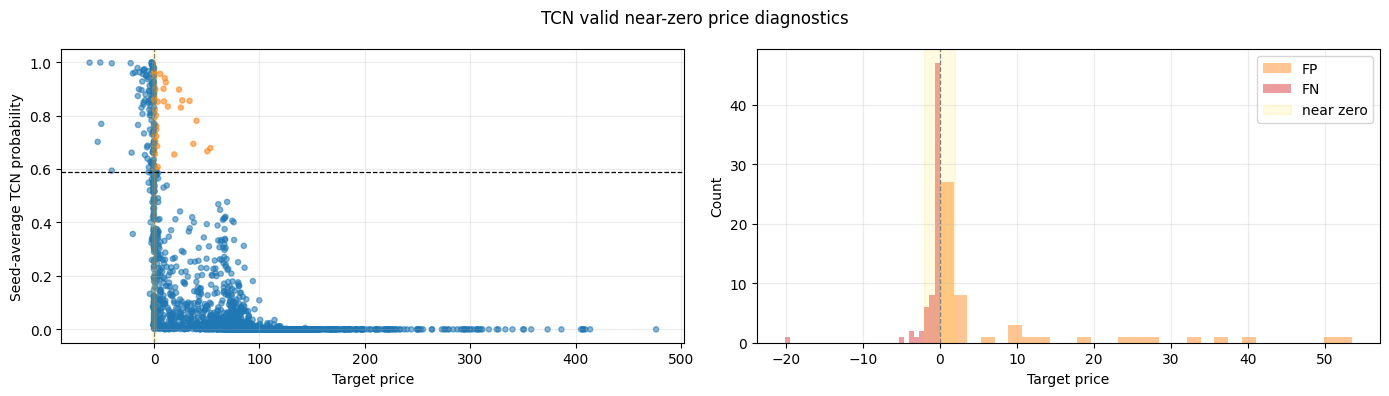

In [14]:
classification_diag = pd.DataFrame({
    "timestamp": times_valid,
    "y_true": y_valid.astype(int),
    "y_prob": avg_scores,
    "Price": price_valid,
})
classification_diag["y_pred"] = (
    classification_diag["y_prob"] >= best_threshold
).astype(int)
classification_diag["FP"] = (
    classification_diag["y_pred"].eq(1)
    & classification_diag["y_true"].eq(0)
).astype(int)
classification_diag["FN"] = (
    classification_diag["y_pred"].eq(0)
    & classification_diag["y_true"].eq(1)
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
axes[0].scatter(
    classification_diag["Price"],
    classification_diag["y_prob"],
    c=np.where(classification_diag["FP"].eq(1), "tab:orange", "tab:blue"),
    s=14,
    alpha=0.55,
)
axes[0].axhline(best_threshold, color="black", linestyle="--", linewidth=0.9)
axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.9)
axes[0].axvspan(EVAL_TAU_MINUS, EVAL_TAU_PLUS, color="gold", alpha=0.12, label="near zero")
axes[0].set(xlabel="Target price", ylabel="Seed-average TCN probability")
axes[0].grid(alpha=0.25)

error_colors = {"FP": "tab:orange", "FN": "tab:red"}
for error_type, error_column in [("FP", "FP"), ("FN", "FN")]:
    group = classification_diag[classification_diag[error_column].eq(1)]
    if group.empty:
        continue
    axes[1].hist(
        group["Price"],
        bins=30,
        alpha=0.45,
        color=error_colors[error_type],
        label=error_type,
    )
axes[1].axvline(0, color="gray", linestyle="--", linewidth=0.9)
axes[1].axvspan(EVAL_TAU_MINUS, EVAL_TAU_PLUS, color="gold", alpha=0.12, label="near zero")
axes[1].set(xlabel="Target price", ylabel="Count")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.25)

fig.suptitle("TCN valid near-zero price diagnostics")
plt.tight_layout()


### price-severity loss tuning


In [15]:
PRICE_LOSS_TUNING_STAGES = [
    ("tau_plus", [0.0, 2.0, 5.0, 10.0]),
    ("tau_minus", [0.0, -1.0, -2.0, -5.0]),
    ("lambda_plus", [0.5, 1.0, 2.0, 5.0, 10.0]),
    ("lambda_minus", [0.5, 1.0, 2.0, 5.0, 10.0]),
    ("beta_plus", [1.0, 1.5, 2.0, 3.0, 4.0]),
    ("beta_minus", [1.0, 1.5, 2.0, 3.0, 4.0]),
    ("max_weight", [5.0, 10.0, 20.0, 50.0, None]),
]


def run_price_loss_coordinate_search(start_params, stages, max_rounds=2):
    current_params = dict(start_params)
    stage_rows = []
    all_candidate_rows = []

    for round_number in range(1, max_rounds + 1):
        round_start_params = dict(current_params)

        for parameter_name, candidates in stages:
            candidate_rows = []
            for candidate in candidates:
                candidate_params = {
                    **current_params,
                    parameter_name: candidate,
                }
                runs = train_price_severity_classifier(
                    forecast_dataset,
                    price_train,
                    price_valid,
                    candidate_params,
                    TCN_CONFIG,
                    SEEDS,
                    verbose=False,
                )
                result, _, _, _ = evaluate_price_severity_runs(
                    runs,
                    SEEDS,
                    y_valid,
                    price_valid,
                )
                candidate_rows.append({
                    "round": round_number,
                    "parameter": parameter_name,
                    "candidate": candidate,
                    **result,
                })

            candidate_table = pd.DataFrame(candidate_rows).sort_values(
                ["severe_errors", "f1", "pr_auc"],
                ascending=[True, False, False],
            ).reset_index(drop=True)
            all_candidate_rows.extend(candidate_rows)

            selected_row = candidate_table.iloc[0].to_dict()
            selected_value = selected_row["candidate"]
            if pd.isna(selected_value):
                selected_value = None
            current_params[parameter_name] = selected_value
            stage_rows.append({
                **selected_row,
                "selected_value": selected_value,
            })
            print(
                f"round {round_number}, {parameter_name}: "
                f"selected={selected_value}, "
                f"severe_errors={int(selected_row['severe_errors'])}, "
                f"f1={selected_row['f1']:.4f}, "
                f"pr_auc={selected_row['pr_auc']:.4f}"
            )

        if current_params == round_start_params:
            print(f"No parameter changed in round {round_number}; stopping.")
            break

    return (
        current_params,
        pd.DataFrame(stage_rows),
        pd.DataFrame(all_candidate_rows),
    )


RUN_FULL_LOSS_TUNING = True
if RUN_FULL_LOSS_TUNING:
    best_loss_params, loss_tuning_summary, loss_tuning_candidates = (
        run_price_loss_coordinate_search(
            LOSS_PARAMS,
            PRICE_LOSS_TUNING_STAGES,
            max_rounds=2,
        )
    )
    display(pd.Series(best_loss_params))
    display(loss_tuning_summary)
else:
    print("Set RUN_FULL_LOSS_TUNING = True to run the full loss search.")


round 1, tau_plus: selected=0.0, severe_errors=28, f1=0.6366, pr_auc=0.7082
round 1, tau_minus: selected=-2.0, severe_errors=28, f1=0.6366, pr_auc=0.7082
round 1, lambda_plus: selected=1.0, severe_errors=28, f1=0.6366, pr_auc=0.7082
round 1, lambda_minus: selected=5.0, severe_errors=24, f1=0.6188, pr_auc=0.7045
round 1, beta_plus: selected=2.0, severe_errors=24, f1=0.6188, pr_auc=0.7045
round 1, beta_minus: selected=2.0, severe_errors=24, f1=0.6188, pr_auc=0.7045
round 1, max_weight: selected=20.0, severe_errors=24, f1=0.6188, pr_auc=0.7045
round 2, tau_plus: selected=5.0, severe_errors=24, f1=0.6386, pr_auc=0.7082
round 2, tau_minus: selected=-2.0, severe_errors=24, f1=0.6386, pr_auc=0.7082
round 2, lambda_plus: selected=5.0, severe_errors=23, f1=0.5906, pr_auc=0.7155
round 2, lambda_minus: selected=5.0, severe_errors=23, f1=0.5906, pr_auc=0.7155
round 2, beta_plus: selected=2.0, severe_errors=23, f1=0.5906, pr_auc=0.7155
round 2, beta_minus: selected=1.0, severe_errors=23, f1=0.6296,

tau_plus         5.0
tau_minus       -2.0
s_plus           NaN
s_minus          NaN
beta_plus        2.0
beta_minus       1.0
lambda_plus      5.0
lambda_minus     5.0
max_weight      20.0
dtype: float64

,round,parameter,candidate,severe_errors,FP_>2,FN_<-2,f1,precision,recall,pr_auc,selected_threshold,TP,FP,FN,TN,selected_value
0,1,tau_plus,0.0,28.0,16.0,12.0,0.636637,0.711409,0.576087,0.708150,0.490949,106.0,43.0,78.0,3445.0,0.0
1,1,tau_minus,-2.0,28.0,16.0,12.0,0.636637,0.711409,0.576087,0.708150,0.490949,106.0,43.0,78.0,3445.0,-2.0
2,1,lambda_plus,1.0,28.0,16.0,12.0,0.636637,0.711409,0.576087,0.708150,0.490949,106.0,43.0,78.0,3445.0,1.0
3,1,lambda_minus,5.0,24.0,12.0,12.0,0.618750,0.727941,0.538043,0.704547,0.648473,99.0,37.0,85.0,3451.0,5.0
4,1,beta_plus,2.0,24.0,12.0,12.0,0.618750,0.727941,0.538043,0.704547,0.648473,99.0,37.0,85.0,3451.0,2.0
5,1,beta_minus,2.0,24.0,12.0,12.0,0.618750,0.727941,0.538043,0.704547,0.648473,99.0,37.0,85.0,3451.0,2.0
6,1,max_weight,20.0,24.0,12.0,12.0,0.618750,0.727941,0.538043,0.704547,0.648473,99.0,37.0,85.0,3451.0,20.0
7,2,tau_plus,5.0,24.0,13.0,11.0,0.638554,0.716216,0.576087,0.708204,0.648104,106.0,42.0,78.0,3446.0,5.0
8,2,tau_minus,-2.0,24.0,13.0,11.0,0.638554,0.716216,0.576087,0.708204,0.648104,106.0,42.0,78.0,3446.0,-2.0
9,2,lambda_plus,5.0,23.0,7.0,16.0,0.590604,0.771930,0.478261,0.715509,0.699720,88.0,26.0,96.0,3462.0,5.0


With the usual focal loss, there are 23 FP>2 and 8 FN <-2; this setup does reduce high absolute price errors but F1 and pr_auc are not as good.

## Experiment 2: TCN Price Regression


In [16]:
REGRESSION_LOSS_PARAMS = {
    "huber_delta": 5.0,
}
THRESHOLD_FOR_REPORT = 0.0

pd.Series(price_train).describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).to_frame("train_price")



,train_price
count,11617.000000
mean,84.312233
std,56.824154
min,-250.320007
1%,-29.012801
5%,-0.502000
50%,87.120003
95%,159.466003
99%,231.026399
max,936.280029


### Train the regression model


In [17]:
def make_loader(X, y, price, batch_size, shuffle):
    data = torch.utils.data.TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
        torch.tensor(price, dtype=torch.float32),
    )
    return torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=shuffle)


def predict_price(model, loader):
    model.eval()
    pred_prices = []
    targets = []
    prices = []
    with torch.no_grad():
        for X_batch, y_batch, price_batch in loader:
            pred = model(X_batch.to(DEVICE))
            pred_prices.append(pred.cpu().numpy())
            targets.append(y_batch.numpy())
            prices.append(price_batch.numpy())
    return np.concatenate(pred_prices), np.concatenate(targets), np.concatenate(prices)


def price_metrics(y_true, pred_price, price, threshold=0.0):
    y_pred = pred_price <= threshold
    return {
        "mae": float(np.mean(np.abs(pred_price - price))),
        "rmse": float(np.sqrt(np.mean((pred_price - price) ** 2))),
        "price_corr": float(np.corrcoef(pred_price, price)[0, 1]) if len(pred_price) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, -pred_price) if len(np.unique(y_true)) > 1 else 0.0,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }


def summarize_errors(y_true, pred_price, price, threshold=0.0, tau_plus=EVAL_TAU_PLUS, tau_minus=EVAL_TAU_MINUS):
    pred = (pred_price <= threshold).astype(int)
    rows = []
    for name, mask in {
        "FP": (pred == 1) & (y_true == 0),
        "FN": (pred == 0) & (y_true == 1),
        "TP": (pred == 1) & (y_true == 1),
        "TN": (pred == 0) & (y_true == 0),
    }.items():
        p = price[mask]
        pred_p = pred_price[mask]
        rows.append({
            "type": name,
            "count": int(mask.sum()),
            "price_mean": np.nan if len(p) == 0 else float(np.mean(p)),
            "price_p10": np.nan if len(p) == 0 else float(np.quantile(p, 0.10)),
            "price_median": np.nan if len(p) == 0 else float(np.median(p)),
            "price_p90": np.nan if len(p) == 0 else float(np.quantile(p, 0.90)),
            "pred_price_mean": np.nan if len(pred_p) == 0 else float(np.mean(pred_p)),
            "outside_near_zero_rate": np.nan if len(p) == 0 else float(np.mean((p > tau_plus) | (p < tau_minus))),
        })
    return pd.DataFrame(rows)


def train_candidate(loss_params, candidate_name="tcn_regression", seeds=SEEDS, verbose=True):
    train_loader = make_loader(X_train, y_train, price_train, TCN_CONFIG["batch_size"], shuffle=True)
    valid_loader = make_loader(X_valid, y_valid, price_valid, TCN_CONFIG["batch_size"], shuffle=False)

    runs = {}
    for seed in seeds:
        set_random_seed(seed)
        model = CurtailmentTCN(
            input_dim=X_train.shape[2],
            channels=TCN_CONFIG["channels"],
            kernel_size=TCN_CONFIG["kernel_size"],
            dropout=TCN_CONFIG["dropout"],
        ).to(DEVICE)
        criterion = nn.HuberLoss(delta=loss_params["huber_delta"])
        optimizer = optim.Adam(model.parameters(), lr=TCN_CONFIG["learning_rate"])

        best_state = None
        best_valid_loss = np.inf
        best_epoch = 0
        bad_epochs = 0
        history = []

        for epoch in range(TCN_CONFIG["epochs"]):
            model.train()
            losses = []
            for X_batch, y_batch, price_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                price_batch = price_batch.to(DEVICE)

                optimizer.zero_grad()
                pred_price = model(X_batch)
                loss = criterion(pred_price, price_batch)
                loss.backward()
                optimizer.step()
                losses.append(loss.item())

            valid_pred_price, valid_true, valid_price = predict_price(model, valid_loader)
            valid_tensor = torch.tensor(valid_pred_price, dtype=torch.float32, device=DEVICE)
            price_tensor = torch.tensor(valid_price, dtype=torch.float32, device=DEVICE)
            valid_loss = float(criterion(valid_tensor, price_tensor).item())
            metrics = price_metrics(valid_true, valid_pred_price, valid_price, threshold=THRESHOLD_FOR_REPORT)
            history.append({
                "epoch": epoch + 1,
                "train_loss": float(np.mean(losses)),
                "valid_loss": valid_loss,
                "valid_mae": metrics["mae"],
                "valid_rmse": metrics["rmse"],
                "valid_price_corr": metrics["price_corr"],
                "valid_PR_AUC_from_negative_pred_price": metrics["pr_auc"],
                f"valid_F1_at_price_threshold_{THRESHOLD_FOR_REPORT:g}": metrics["f1"],
            })

            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                best_epoch = epoch + 1
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1

            if verbose:
                print(
                    candidate_name,
                    seed,
                    epoch + 1,
                    f"loss={np.mean(losses):.4f}",
                    f"valid_loss={valid_loss:.4f}",
                    f"mae={metrics['mae']:.3f}",
                    f"pr_auc={metrics['pr_auc']:.4f}",
                    f"f1@price<={THRESHOLD_FOR_REPORT:g}={metrics['f1']:.4f}",
                )
            if bad_epochs >= TCN_CONFIG["patience"]:
                break

        model.load_state_dict(best_state)
        valid_pred_price, valid_true, valid_price = predict_price(model, valid_loader)
        metrics = price_metrics(valid_true, valid_pred_price, valid_price, threshold=THRESHOLD_FOR_REPORT)
        runs[seed] = {
            "history": pd.DataFrame(history),
            "best_epoch": best_epoch,
            "valid_pred_price": valid_pred_price,
            "valid_true": valid_true,
            "valid_price": valid_price,
            "valid_loss": best_valid_loss,
            "valid_mae": metrics["mae"],
            "valid_rmse": metrics["rmse"],
            "valid_price_corr": metrics["price_corr"],
            "valid_PR_AUC": metrics["pr_auc"],
            "valid_F1_at_report_threshold": metrics["f1"],
        }
        if verbose:
            print("best", candidate_name, seed, best_epoch, f"valid_loss={best_valid_loss:.4f}")
    return runs


def seed_average_predictions(runs, seeds=SEEDS):
    for seed in seeds:
        assert np.array_equal(runs[seed]["valid_true"], y_valid)
        assert np.array_equal(runs[seed]["valid_price"], price_valid)

    valid_predictions = pd.DataFrame([
        runs[seed]["valid_pred_price"]
        for seed in seeds
    ], index=seeds)
    return valid_predictions.mean(axis=0).to_numpy(), valid_predictions


def threshold_sweep_by_severity(pred_prices, y_true, prices, eval_tau_plus=EVAL_TAU_PLUS, eval_tau_minus=EVAL_TAU_MINUS):
    fixed_thresholds = np.array([eval_tau_minus, 0.0, eval_tau_plus])
    thresholds = np.sort(np.unique(np.concatenate([pred_prices, fixed_thresholds])))
    pr_auc = average_precision_score(y_true, -pred_prices) if len(np.unique(y_true)) > 1 else 0.0
    mae = float(np.mean(np.abs(pred_prices - prices)))
    rmse = float(np.sqrt(np.mean((pred_prices - prices) ** 2)))
    price_corr = float(np.corrcoef(pred_prices, prices)[0, 1]) if len(pred_prices) > 1 else np.nan
    rows = []
    y_true_bool = y_true.astype(bool)

    for threshold in thresholds:
        y_pred = pred_prices <= threshold
        tp = y_pred & y_true_bool
        fp = y_pred & ~y_true_bool
        fn = ~y_pred & y_true_bool
        tn = ~y_pred & ~y_true_bool

        tp_count = int(tp.sum())
        fp_count = int(fp.sum())
        fn_count = int(fn.sum())
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        fp_high = int((fp & (prices > eval_tau_plus)).sum())
        fn_deep = int((fn & (prices < eval_tau_minus)).sum())

        rows.append({
            "severe_errors": fp_high + fn_deep,
            f"FP_>{eval_tau_plus:g}": fp_high,
            f"FN_<{eval_tau_minus:g}": fn_deep,
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "pr_auc": pr_auc,
            "mae": mae,
            "rmse": rmse,
            "price_corr": price_corr,
            "selected_price_threshold": float(threshold),
            "FP": fp_count,
            "FN": fn_count,
            "TP": tp_count,
            "TN": int(tn.sum()),
        })

    table = pd.DataFrame(rows).sort_values(
        ["severe_errors", "f1", "pr_auc"],
        ascending=[True, False, False],
    ).reset_index(drop=True)
    return table.iloc[0].to_dict(), table


def evaluate_candidate(candidate_name, loss_params, runs, seeds=SEEDS):
    avg_pred_price, valid_predictions = seed_average_predictions(runs, seeds=seeds)
    selected, threshold_table = threshold_sweep_by_severity(avg_pred_price, y_valid, price_valid)
    result = {
        "severe_errors": selected["severe_errors"],
        f"FP_>{EVAL_TAU_PLUS:g}": selected[f"FP_>{EVAL_TAU_PLUS:g}"],
        f"FN_<{EVAL_TAU_MINUS:g}": selected[f"FN_<{EVAL_TAU_MINUS:g}"],
        "f1": selected["f1"],
        "precision": selected["precision"],
        "recall": selected["recall"],
        "pr_auc": selected["pr_auc"],
        "mae": selected["mae"],
        "rmse": selected["rmse"],
        "price_corr": selected["price_corr"],
        "selected_price_threshold": selected["selected_price_threshold"],
        "candidate": candidate_name,
        **loss_params,
        "FP": selected["FP"],
        "FN": selected["FN"],
        "TP": selected["TP"],
        "TN": selected["TN"],
    }
    return result, threshold_table, avg_pred_price, valid_predictions


def result_columns(frame):
    leading = [
        "severe_errors",
        f"FP_>{EVAL_TAU_PLUS:g}",
        f"FN_<{EVAL_TAU_MINUS:g}",
        "f1",
        "precision",
        "recall",
        "pr_auc",
        "mae",
        "rmse",
        "price_corr",
        "selected_price_threshold",
        "candidate",
    ]
    return [col for col in leading if col in frame.columns] + [col for col in frame.columns if col not in leading]


def display_result_table(frame):
    return frame.loc[:, result_columns(frame)]


def make_valid_diag(pred_prices, threshold):
    preds = (pred_prices <= threshold).astype(int)
    diag = pd.DataFrame({
        "timestamp": times_valid,
        "y_true": y_valid.astype(int),
        "y_pred_price": pred_prices,
        "y_pred": preds,
        "Price": price_valid,
    })
    diag["price_error"] = diag["y_pred_price"] - diag["Price"]
    diag["abs_price_error"] = diag["price_error"].abs()
    diag["FP"] = (diag["y_pred"].eq(1) & diag["y_true"].eq(0)).astype(int)
    diag["FN"] = (diag["y_pred"].eq(0) & diag["y_true"].eq(1)).astype(int)
    diag["TP"] = (diag["y_pred"].eq(1) & diag["y_true"].eq(1)).astype(int)
    diag["TN"] = (diag["y_pred"].eq(0) & diag["y_true"].eq(0)).astype(int)
    diag["error_type"] = np.select(
        [diag["TP"].eq(1), diag["FP"].eq(1), diag["FN"].eq(1), diag["TN"].eq(1)],
        ["TP", "FP", "FN", "TN"],
        default="unknown",
    )
    return diag

In [18]:
all_runs = train_candidate(loss_params=REGRESSION_LOSS_PARAMS, candidate_name="tcn_regression", seeds=SEEDS, verbose=True)

tcn_regression 1 1 loss=167.1728 valid_loss=118.4783 mae=26.076 pr_auc=0.6054 f1@price<=0=0.0000
tcn_regression 1 2 loss=89.7029 valid_loss=90.9176 mae=20.555 pr_auc=0.6235 f1@price<=0=0.5017
tcn_regression 1 3 loss=74.0404 valid_loss=76.1083 mae=17.554 pr_auc=0.6732 f1@price<=0=0.5952
tcn_regression 1 4 loss=67.7615 valid_loss=72.4309 mae=16.798 pr_auc=0.6758 f1@price<=0=0.5913
tcn_regression 1 5 loss=64.8757 valid_loss=72.2253 mae=16.744 pr_auc=0.6236 f1@price<=0=0.5707
tcn_regression 1 6 loss=61.5385 valid_loss=73.5197 mae=17.016 pr_auc=0.6866 f1@price<=0=0.6313
tcn_regression 1 7 loss=59.8633 valid_loss=68.8662 mae=16.070 pr_auc=0.6668 f1@price<=0=0.6188
tcn_regression 1 8 loss=57.3016 valid_loss=70.8766 mae=16.493 pr_auc=0.6556 f1@price<=0=0.6029
tcn_regression 1 9 loss=56.4897 valid_loss=81.1874 mae=18.589 pr_auc=0.6524 f1@price<=0=0.5584
tcn_regression 1 10 loss=54.7107 valid_loss=69.4376 mae=16.164 pr_auc=0.6379 f1@price<=0=0.5968
best tcn_regression 1 7 valid_loss=68.8662
tcn_

### Seed-average regression validation evaluation


In [19]:
candidate_result, threshold_check, avg_pred_price, valid_predictions = evaluate_candidate(
    "tcn_regression",
    REGRESSION_LOSS_PARAMS,
    all_runs,
    seeds=SEEDS,
)

best_threshold = candidate_result["selected_price_threshold"]
avg_preds = (avg_pred_price <= best_threshold).astype(int)
avg_precision = candidate_result["precision"]
avg_recall = candidate_result["recall"]
avg_f1 = candidate_result["f1"]
avg_pr_auc = candidate_result["pr_auc"]

seed_summary = pd.DataFrame({
    seed: {
        "best_epoch": all_runs[seed]["best_epoch"],
        "valid_loss": all_runs[seed]["valid_loss"],
        "valid_mae": all_runs[seed]["valid_mae"],
        "valid_rmse": all_runs[seed]["valid_rmse"],
        "valid_price_corr": all_runs[seed]["valid_price_corr"],
        "valid_PR_AUC": all_runs[seed]["valid_PR_AUC"],
        f"valid_F1_at_price_threshold_{THRESHOLD_FOR_REPORT:g}": all_runs[seed]["valid_F1_at_report_threshold"],
    }
    for seed in SEEDS
}).T

print("Per-seed validation summary")
display(seed_summary)
print("Selected by fixed-tau severe error, with F1 as tie-break")
display(pd.Series(candidate_result).reindex(result_columns(pd.DataFrame([candidate_result]))))

display_result_table(threshold_check).head(20)

Per-seed validation summary


,best_epoch,valid_loss,valid_mae,valid_rmse,valid_price_corr,valid_PR_AUC,valid_F1_at_price_threshold_0
1,7.0,68.866188,16.069662,25.801249,0.858189,0.666791,0.618785
2,8.0,67.327736,15.763890,25.050617,0.866303,0.620905,0.539394
3,6.0,68.464050,15.986512,25.327854,0.862503,0.651333,0.595506


Selected by fixed-tau severe error, with F1 as tie-break


severe_errors                         43.0
FP_>2                                 17.0
FN_<-2                                26.0
f1                                0.582822
precision                         0.669014
recall                            0.516304
pr_auc                             0.65394
mae                              15.591439
rmse                             25.062721
price_corr                         0.86593
selected_price_threshold         -1.378286
candidate                   tcn_regression
huber_delta                            5.0
FP                                    47.0
FN                                    89.0
TP                                    95.0
TN                                  3441.0
dtype: object

,severe_errors,FP_>2,FN_<-2,f1,precision,recall,pr_auc,mae,rmse,price_corr,selected_price_threshold,FP,FN,TP,TN
0,43,17,26,0.582822,0.669014,0.516304,0.65394,15.591439,25.062721,0.86593,-1.378286,47,89,95,3441
1,43,14,29,0.581470,0.705426,0.494565,0.65394,15.591439,25.062721,0.86593,-2.486465,38,93,91,3450
2,43,14,29,0.576923,0.703125,0.489130,0.65394,15.591439,25.062721,0.86593,-2.531699,38,94,90,3450
3,43,14,29,0.574194,0.706349,0.483696,0.65394,15.591439,25.062721,0.86593,-2.617212,37,95,89,3451
4,43,14,29,0.572347,0.700787,0.483696,0.65394,15.591439,25.062721,0.86593,-2.607426,38,95,89,3450
5,44,16,28,0.584906,0.694030,0.505435,0.65394,15.591439,25.062721,0.86593,-1.957743,41,91,93,3447
6,44,16,28,0.583072,0.688889,0.505435,0.65394,15.591439,25.062721,0.86593,-1.955497,42,91,93,3446
7,44,16,28,0.581250,0.683824,0.505435,0.65394,15.591439,25.062721,0.86593,-1.792744,43,91,93,3445
8,44,18,26,0.581040,0.664336,0.516304,0.65394,15.591439,25.062721,0.86593,-1.322059,48,89,95,3440
9,44,17,27,0.580247,0.671429,0.510870,0.65394,15.591439,25.062721,0.86593,-1.567155,46,90,94,3442


### Regression validation diagnostics


In [20]:
tcn_valid_diag = make_valid_diag(avg_pred_price, best_threshold)

tcn_valid_total = pd.Series({
    "selected_price_threshold": best_threshold,
    "size": len(tcn_valid_diag),
    "positive": int(tcn_valid_diag["y_true"].sum()),
    "negative": int(tcn_valid_diag["y_true"].eq(0).sum()),
    "TP": int(tcn_valid_diag["TP"].sum()),
    "FP": int(tcn_valid_diag["FP"].sum()),
    "FN": int(tcn_valid_diag["FN"].sum()),
    "TN": int(tcn_valid_diag["TN"].sum()),
    f"FP_>{EVAL_TAU_PLUS:g}": candidate_result[f"FP_>{EVAL_TAU_PLUS:g}"],
    f"FN_<{EVAL_TAU_MINUS:g}": candidate_result[f"FN_<{EVAL_TAU_MINUS:g}"],
    "severe_errors": candidate_result["severe_errors"],
    "precision": avg_precision,
    "recall": avg_recall,
    "f1": avg_f1,
    "pr_auc": avg_pr_auc,
    "mae": candidate_result["mae"],
    "rmse": candidate_result["rmse"],
    "price_corr": candidate_result["price_corr"],
})

month = pd.DatetimeIndex(tcn_valid_diag["timestamp"]).month
tcn_valid_diag["season"] = np.select(
    [month.isin([12, 1, 2]), month.isin([3, 4, 5]), month.isin([6, 7, 8])],
    ["winter", "spring", "summer"],
    default="autumn",
)
tcn_valid_diag["hour"] = pd.DatetimeIndex(tcn_valid_diag["timestamp"]).hour

tcn_valid_season = tcn_valid_diag.groupby("season", sort=False).agg(
    size=("y_true", "size"),
    positive=("y_true", "sum"),
    FP=("FP", "sum"),
    FN=("FN", "sum"),
    TP=("TP", "sum"),
    TN=("TN", "sum"),
    mae=("abs_price_error", "mean"),
)
tcn_valid_season["precision"] = tcn_valid_season["TP"] / (tcn_valid_season["TP"] + tcn_valid_season["FP"]).replace(0, np.nan)
tcn_valid_season["recall"] = tcn_valid_season["TP"] / (tcn_valid_season["TP"] + tcn_valid_season["FN"]).replace(0, np.nan)
tcn_valid_season["f1"] = 2 * tcn_valid_season["TP"] / (2 * tcn_valid_season["TP"] + tcn_valid_season["FP"] + tcn_valid_season["FN"]).replace(0, np.nan)

print("TCN regression seed-average valid total")
display(tcn_valid_total.to_frame("value"))
print("TCN regression seed-average valid by season")
display(tcn_valid_season)

tcn_valid_diag.sort_values("y_pred_price").head(20)

TCN regression seed-average valid total


,value
selected_price_threshold,-1.378286
size,3672.000000
positive,184.000000
negative,3488.000000
TP,95.000000
FP,47.000000
FN,89.000000
TN,3441.000000
FP_>2,17.000000
FN_<-2,26.000000


TCN regression seed-average valid by season


,size,positive,FP,FN,TP,TN,mae,precision,recall,f1
season,,,,,,,,,,
summer,1488,76,40,23,53,1372,13.492739,0.569892,0.697368,0.627219
autumn,2184,108,7,66,42,2069,17.021324,0.857143,0.388889,0.535032


,timestamp,y_true,y_pred_price,y_pred,Price,price_error,abs_price_error,FP,FN,TP,TN,error_type,season,hour
972,2025-08-10 12:00:00+00:00,1,-27.219919,1,-50.939999,23.720079,23.720079,0,0,1,0,TP,summer,12
971,2025-08-10 11:00:00+00:00,1,-25.996637,1,-61.080002,35.083366,35.083366,0,0,1,0,TP,summer,11
973,2025-08-10 13:00:00+00:00,1,-24.117004,1,-22.120001,-1.997004,1.997004,0,0,1,0,TP,summer,13
108,2025-07-05 12:00:00+00:00,1,-22.719496,1,-2.110000,-20.609495,20.609495,0,0,1,0,TP,summer,12
970,2025-08-10 10:00:00+00:00,1,-21.999445,1,-40.029999,18.030554,18.030554,0,0,1,0,TP,summer,10
107,2025-07-05 11:00:00+00:00,1,-21.814920,1,-2.050000,-19.764921,19.764921,0,0,1,0,TP,summer,11
109,2025-07-05 13:00:00+00:00,1,-20.176565,1,-2.010000,-18.166565,18.166565,0,0,1,0,TP,summer,13
1979,2025-09-21 11:00:00+00:00,1,-18.737762,1,-2.020000,-16.717762,16.717762,0,0,1,0,TP,autumn,11
106,2025-07-05 10:00:00+00:00,1,-18.504553,1,-1.010000,-17.494553,17.494553,0,0,1,0,TP,summer,10
1978,2025-09-21 10:00:00+00:00,1,-18.335619,1,-1.200000,-17.135618,17.135618,0,0,1,0,TP,autumn,10


In [21]:
valid_summary = summarize_errors(
    tcn_valid_diag["y_true"].to_numpy(),
    tcn_valid_diag["y_pred_price"].to_numpy(),
    tcn_valid_diag["Price"].to_numpy(),
    threshold=best_threshold,
    tau_plus=EVAL_TAU_PLUS,
    tau_minus=EVAL_TAU_MINUS,
)
valid_summary

,type,count,price_mean,price_p10,price_median,price_p90,pred_price_mean,outside_near_zero_rate
0,FP,47,3.185532,0.000,0.220000,10.636000,-7.342114,0.361702
1,FN,89,-2.103820,-5.110,-0.520000,-0.010000,10.910108,0.292135
2,TP,95,-6.707158,-15.508,-1.980000,-0.010000,-9.988194,0.494737
3,TN,3441,92.856651,41.660,91.440002,128.080002,89.369095,0.980529


Near-zero definition: -2.0 <= Price <= 2.0
TCN regression seed-average valid FP severity


,count,price_mean,price_median
fp_severity,,,
low_price_fp,17,8.489412,8.97
near_zero_fp,30,0.180000,0.00


TCN regression seed-average valid FN severity


,count,price_mean,price_median
fn_severity,,,
deep_negative_fn,1,-20.049999,-20.049999
moderate_negative_fn,25,-5.666000,-4.460000
near_zero_fn,63,-0.405397,-0.100000


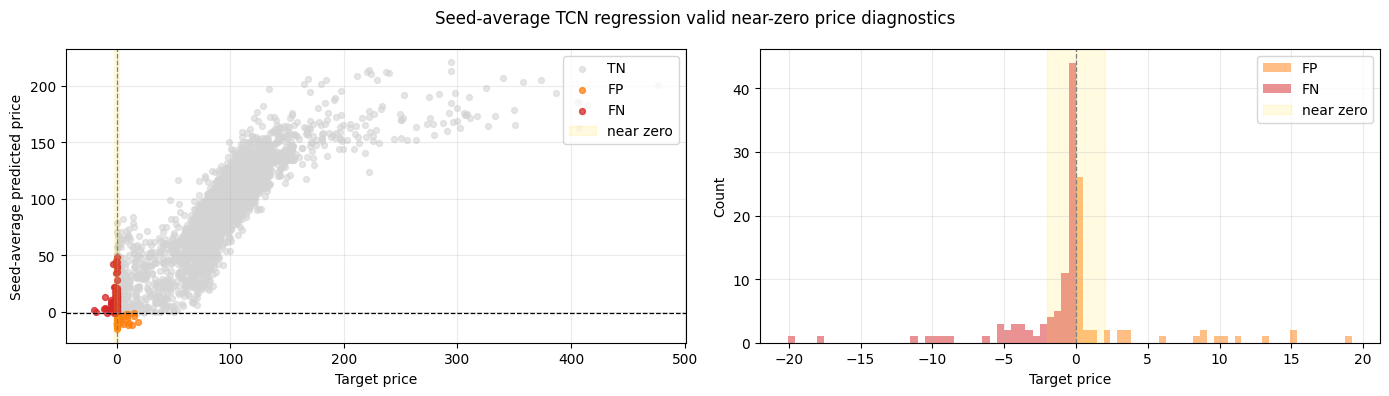

In [22]:
# Near-zero price severity diagnostics for seed-average valid errors.
from IPython.display import display

tau_plus = EVAL_TAU_PLUS
tau_minus = EVAL_TAU_MINUS

near_zero_context = tcn_valid_diag.copy()
near_zero_context["near_zero"] = near_zero_context["Price"].between(tau_minus, tau_plus, inclusive="both")
near_zero_context["fp_severity"] = np.where(
    near_zero_context["FP"].eq(1),
    np.select(
        [
            near_zero_context["Price"].le(tau_plus),
            near_zero_context["Price"].le(20),
            near_zero_context["Price"].gt(20),
        ],
        ["near_zero_fp", "low_price_fp", "high_price_fp"],
        default="not_fp",
    ),
    "not_fp",
)
near_zero_context["fn_severity"] = np.where(
    near_zero_context["FN"].eq(1),
    np.select(
        [
            near_zero_context["Price"].ge(tau_minus),
            near_zero_context["Price"].ge(-20),
            near_zero_context["Price"].lt(-20),
        ],
        ["near_zero_fn", "moderate_negative_fn", "deep_negative_fn"],
        default="not_fn",
    ),
    "not_fn",
)

fp_severity_summary = near_zero_context[near_zero_context["FP"].eq(1)].groupby("fp_severity").agg(
    count=("y_true", "size"),
    price_mean=("Price", "mean"),
    price_median=("Price", "median"),
)
fn_severity_summary = near_zero_context[near_zero_context["FN"].eq(1)].groupby("fn_severity").agg(
    count=("y_true", "size"),
    price_mean=("Price", "mean"),
    price_median=("Price", "median"),
)

fp_order = ["high_price_fp", "low_price_fp", "near_zero_fp"]
fn_order = ["deep_negative_fn", "moderate_negative_fn", "near_zero_fn"]
fp_severity_summary = fp_severity_summary.reindex([x for x in fp_order if x in fp_severity_summary.index])
fn_severity_summary = fn_severity_summary.reindex([x for x in fn_order if x in fn_severity_summary.index])

print("Near-zero definition:", tau_minus, "<= Price <=", tau_plus)
print("TCN regression seed-average valid FP severity")
display(fp_severity_summary)
print("TCN regression seed-average valid FN severity")
display(fn_severity_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
error_colors = {"FP": "tab:orange", "FN": "tab:red", "TN": "lightgray", "TP": "tab:green"}

for error_type in ["TN", "FP", "FN"]:
    group = near_zero_context[near_zero_context["error_type"].eq(error_type)]
    if group.empty:
        continue
    axes[0].scatter(
        group["Price"],
        group["y_pred_price"],
        s=18,
        alpha=0.55 if error_type == "TN" else 0.75,
        color=error_colors[error_type],
        label=error_type,
    )
axes[0].axhline(best_threshold, color="black", linestyle="--", linewidth=0.9)
axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.9)
axes[0].axvspan(tau_minus, tau_plus, color="gold", alpha=0.12, label="near zero")
axes[0].set_xlabel("Target price")
axes[0].set_ylabel("Seed-average predicted price")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.25)

for error_type in ["FP", "FN"]:
    group = near_zero_context[near_zero_context["error_type"].eq(error_type)]
    if group.empty:
        continue
    axes[1].hist(group["Price"], bins=40, alpha=0.5, color=error_colors[error_type], label=error_type)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=0.9)
axes[1].axvspan(tau_minus, tau_plus, color="gold", alpha=0.12, label="near zero")
axes[1].set_xlabel("Target price")
axes[1].set_ylabel("Count")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.25)

fig.suptitle("Seed-average TCN regression valid near-zero price diagnostics")
plt.tight_layout()

In [23]:
# Compact threshold check: are high-price FP removable by a lower predicted-price threshold?
threshold_offsets = np.array([-10.0, -5.0, -2.0, -1.0, 0.0, 1.0, 2.0, 5.0, 10.0])
threshold_candidates = np.round(best_threshold + threshold_offsets, 3)
threshold_candidates = np.sort(np.unique(np.concatenate([threshold_candidates, np.array([EVAL_TAU_MINUS, 0.0, EVAL_TAU_PLUS])])))

threshold_rows = []
y_true_bool = tcn_valid_diag["y_true"].eq(1)
prices = tcn_valid_diag["Price"]

for threshold in threshold_candidates:
    y_pred = tcn_valid_diag["y_pred_price"].le(threshold)
    tp = y_pred & y_true_bool
    fp = y_pred & ~y_true_bool
    fn = ~y_pred & y_true_bool
    tn = ~y_pred & ~y_true_bool

    tp_count = int(tp.sum())
    fp_count = int(fp.sum())
    fn_count = int(fn.sum())
    precision = tp_count / (tp_count + fp_count) if tp_count + fp_count else np.nan
    recall = tp_count / (tp_count + fn_count) if tp_count + fn_count else np.nan
    f1 = 2 * tp_count / (2 * tp_count + fp_count + fn_count) if 2 * tp_count + fp_count + fn_count else np.nan

    fp_prices = prices[fp]
    fn_prices = prices[fn]
    fp_high = int(fp_prices.gt(EVAL_TAU_PLUS).sum())
    fn_deep = int(fn_prices.lt(EVAL_TAU_MINUS).sum())
    threshold_rows.append({
        "severe_errors": fp_high + fn_deep,
        f"FP_>{EVAL_TAU_PLUS:g}": fp_high,
        f"FN_<{EVAL_TAU_MINUS:g}": fn_deep,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "price_threshold": threshold,
        "is_selected_threshold": np.isclose(threshold, round(best_threshold, 3)),
        "TP": tp_count,
        "FP": fp_count,
        "FN": fn_count,
        "TN": int(tn.sum()),
        "FP_price_median": fp_prices.median(),
        "FP_>10": int(fp_prices.gt(10).sum()),
        "FP_>20": int(fp_prices.gt(20).sum()),
        f"FN_>{EVAL_TAU_MINUS:g}": int(fn_prices.between(EVAL_TAU_MINUS, 0, inclusive="both").sum()),
    })

compact_threshold_check = pd.DataFrame(threshold_rows).sort_values(
    ["severe_errors", "f1"],
    ascending=[True, False],
)
print("TCN regression seed-average valid compact threshold check")
display(display_result_table(compact_threshold_check))

TCN regression seed-average valid compact threshold check


,severe_errors,FP_>2,FN_<-2,f1,precision,recall,price_threshold,is_selected_threshold,TP,FP,FN,TN,FP_price_median,FP_>10,FP_>20,FN_>-2
5,43,17,26,0.582822,0.669014,0.516304,-1.378,True,95,47,89,3441,0.220,6,0,63
3,43,14,29,0.581470,0.705426,0.494565,-2.378,False,91,38,93,3450,0.195,5,0,64
4,45,16,29,0.575949,0.689394,0.494565,-2.000,False,91,41,93,3447,0.220,5,0,64
1,45,7,38,0.455882,0.704545,0.336957,-6.378,False,62,26,122,3462,0.065,4,0,84
2,47,14,33,0.544850,0.700855,0.445652,-3.378,False,82,35,102,3453,0.220,5,0,69
6,50,27,23,0.574780,0.624204,0.532609,-0.378,False,98,59,86,3429,0.710,11,3,63
7,54,31,23,0.568116,0.608696,0.532609,0.000,False,98,63,86,3425,1.320,13,4,63
8,57,36,21,0.576271,0.600000,0.554348,0.622,False,102,68,82,3420,2.075,16,7,61
0,58,3,55,0.313043,0.782609,0.195652,-11.378,False,36,10,148,3478,0.030,2,0,93
9,60,43,17,0.594164,0.580311,0.608696,2.000,False,112,81,72,3407,2.080,20,11,55


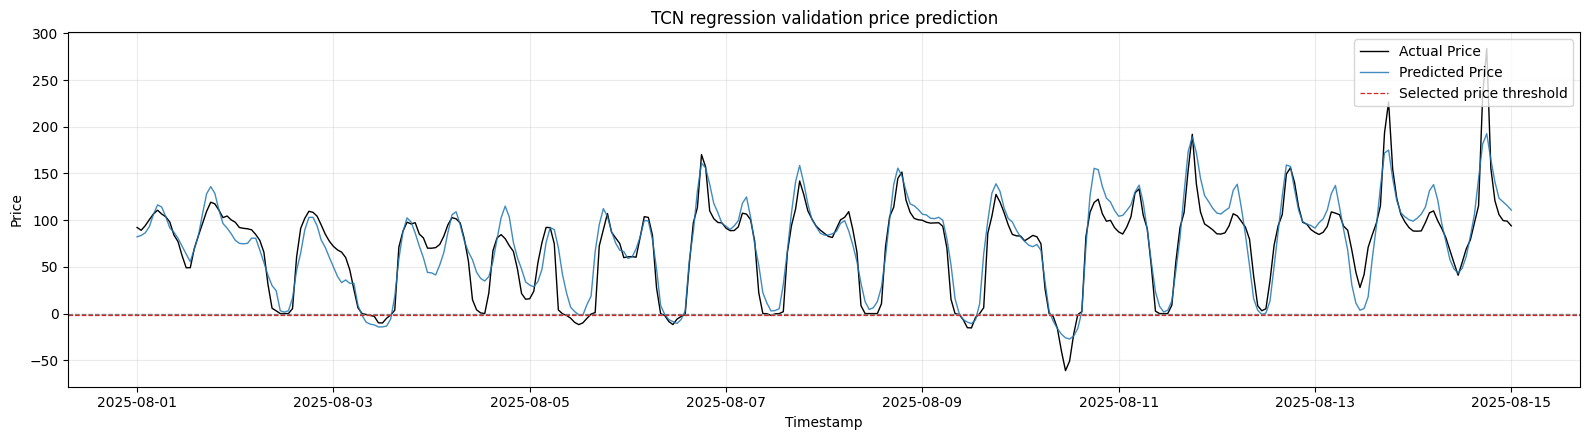

In [24]:
# Actual vs predicted price over validation time.
PRICE_PLOT_START = "2025-08-01"
PRICE_PLOT_END = "2025-08-15"

price_plot = tcn_valid_diag.sort_values("timestamp").copy()
if PRICE_PLOT_START is not None:
    price_plot = price_plot[price_plot["timestamp"].ge(pd.Timestamp(PRICE_PLOT_START, tz="UTC"))]
if PRICE_PLOT_END is not None:
    price_plot = price_plot[price_plot["timestamp"].le(pd.Timestamp(PRICE_PLOT_END, tz="UTC"))]

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(price_plot["timestamp"], price_plot["Price"], color="black", linewidth=1.0, label="Actual Price")
ax.plot(price_plot["timestamp"], price_plot["y_pred_price"], color="tab:blue", linewidth=1.0, alpha=0.85, label="Predicted Price")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.9)
ax.axhline(best_threshold, color="tab:red", linestyle="--", linewidth=0.9, label="Selected price threshold")
ax.set_title("TCN regression validation price prediction")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.25)
plt.tight_layout()
